# Поиск изображений по текстовому запросу

Компания разрабатывает демонстрационную версию сервиса поиска изображений по текстовому запросу.

<b>Цель проекта:</b>

Разработать модель, которая получает векторное представление изображения и текстового запроса и возвращает вероятность соответствия изображения тексту (значение от 0 до 1).         
Модель должна определять, насколько описание подходит к изображению, и использоваться в системе поиска.

___

<b>Задачи проекта:</b>
- Изучить и проанализировать датасет изображений и текстовых описаний
- Cформировать целевую переменную
- Очистить данные с учетом юридических ограничений (исключение изображений с детьми)
- Выполнить векторизацию изображений с использованием предобученной модели компьютерного зрения
- Выполнить векторизацию текстов с использованием мультимодальной модели
- Оценить качество модели (ROC-AUC, F1)
- Реализовать демонстрационный поиск

___

<b>Описание данных</b>

`train_dataset.csv` — обучающая выборка:
- `image` — имя файла изображения
- `query_id` — идентификатор текстового описания
- `query_text` — текст запроса

`train_images`/ — изображения для обучения

`CrowdAnnotations.tsv` — оценки соответствия изображения и текста, полученные от пользователей:
- доля согласившихся
- количество согласившихся
- количество несогласившихся

`ExpertAnnotations.tsv` — оценки соответствия от трёх экспертов (шкала 1–4)

`test_queries.csv` — тестовые запросы:
- текст запроса
- релевантное изображение

`test_images`/ — изображения для тестирования модели

## Загрузка данных

In [34]:
pip install torch==2.6.0 torchvision

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [109]:
import os
import random
import pandas as pd
import matplotlib.pyplot as plt
import textwrap
import matplotlib.image as mpimg
import re
import torch
import torch.nn as nn
from torchvision import models, transforms
from PIL import Image
import torch.nn.functional as F
from transformers import CLIPModel, CLIPProcessor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import roc_auc_score
from sklearn.metrics import f1_score
import numpy as np
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve

In [95]:
TRAIN_PATH = r'C:\Users\malen\OneDrive\Desktop\data_since\cv_nlp\data\train_images'
IMAGE_COL = 'image'
TEST_PATH = r"C:\Users\malen\OneDrive\Desktop\data_since\cv_nlp\data\test_images"
MODEL_NAME = "openai/clip-vit-base-patch32"

In [215]:
train = pd.read_csv('C:/Users/malen/OneDrive/Desktop/data_since/cv_nlp/data/train_dataset.csv')
crowd = pd.read_csv('C:/Users/malen/OneDrive/Desktop/data_since/cv_nlp/data/CrowdAnnotations.tsv', sep='\t', header=None,
    names=[
        'image_name',
        'comment_id',
        'agree_ratio',
        'agree_count',
        'disagree_count'
    ])
expert = pd.read_csv('C:/Users/malen/OneDrive/Desktop/data_since/cv_nlp/data/ExpertAnnotations.tsv', sep='\t', header=None,
    names=[
        'image_name',
        'comment_id',
        'expert_1',
        'expert_2',
        'expert_3'
    ])
test = pd.read_csv('C:/Users/malen/OneDrive/Desktop/data_since/cv_nlp/data/test_queries.csv', sep='|', index_col=0)
test_images = pd.read_csv('C:/Users/malen/OneDrive/Desktop/data_since/cv_nlp/data/test_images.csv')

In [38]:
def show_df_info(df, name='DataFrame'):
    print(f'\n=== {name} ===')

    print('\nПервые строки:')
    display(df.head())

    print('\nИнформация о данных:')
    df.info()

    print('\nОписательная статистика:')
    display(df.describe(include="all"))

show_df_info(train, 'Данные обучения (train)')


=== Данные обучения (train) ===

Первые строки:


,image,query_id,query_text
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
1,1262583859_653f1469a9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
2,2447284966_d6bbdb4b6e.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
3,2549968784_39bfbe44f9.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...
4,2621415349_ef1a7e73be.jpg,2549968784_39bfbe44f9.jpg#2,A young child is wearing blue goggles and sitt...



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image       5822 non-null   object
 1   query_id    5822 non-null   object
 2   query_text  5822 non-null   object
dtypes: object(3)
memory usage: 136.6+ KB

Описательная статистика:


,image,query_id,query_text
count,5822,5822,5822
unique,1000,977,977
top,3364151356_eecd07a23e.jpg,2600867924_cd502fc911.jpg#2,"Two dogs , one brown and white and one black a..."
freq,10,34,34


Данные для обучения содержат 5822 строк с 1000 уникальных изображений, но всего 977 уникальных `query_id`. Скорее всего некоторые `query_id` повторяются. Судя по колическу текст привязан к номеру запроса.
Наиболее часто встречающееся изображение размечалось 10 раз. Один и тот же `query_id` встречается до 34 раз.

In [39]:
train['query_id'].value_counts().head()

query_id
2600867924_cd502fc911.jpg#2    34
1554713437_61b64527dd.jpg#2    27
2522297487_57edf117f7.jpg#2    25
1536774449_e16b1b6382.jpg#2    25
3593392955_a4125087f6.jpg#2    22
Name: count, dtype: int64

Да, описания используются несколько раз в данных.

In [40]:
show_df_info(test, 'Данные тестирования (test)')


=== Данные тестирования (test) ===

Первые строки:


,query_id,query_text,image
0,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt an...",1177994172_10d143cb8d.jpg
1,1177994172_10d143cb8d.jpg#1,Two boys are squirting water guns at each other .,1177994172_10d143cb8d.jpg
2,1177994172_10d143cb8d.jpg#2,Two boys spraying each other with water,1177994172_10d143cb8d.jpg
3,1177994172_10d143cb8d.jpg#3,Two children wearing jeans squirt water at eac...,1177994172_10d143cb8d.jpg
4,1177994172_10d143cb8d.jpg#4,Two young boys are squirting water at each oth...,1177994172_10d143cb8d.jpg



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
Index: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   query_id    500 non-null    object
 1   query_text  500 non-null    object
 2   image       500 non-null    object
dtypes: object(3)
memory usage: 15.6+ KB

Описательная статистика:


,query_id,query_text,image
count,500,500,500
unique,500,500,100
top,1177994172_10d143cb8d.jpg#0,"Two blonde boys , one in a camouflage shirt an...",1177994172_10d143cb8d.jpg
freq,1,1,5


Данные для тестирования содержат 500 строк с 500 уникальных изображений, по одному описанию на одно изображение. Нам надо будет оценить пару тест - фото.

## Исследовательский анализ

### Анализ дубликатов

Проверим выборки на дубликаты

In [41]:
print(train.duplicated().sum())
print(crowd.duplicated().sum())
print(expert.duplicated().sum())
print(test.duplicated().sum())

0
0
0
0


Полных дубликатов, как и пропусков в данных нет.

### Анализ оценок

In [42]:
show_df_info(crowd, 'Оценки от crowd')


=== Оценки от crowd ===

Первые строки:


,image_name,comment_id,agree_ratio,agree_count,disagree_count
0,1056338697_4f7d7ce270.jpg,1056338697_4f7d7ce270.jpg#2,1.0,3,0
1,1056338697_4f7d7ce270.jpg,114051287_dd85625a04.jpg#2,0.0,0,3
2,1056338697_4f7d7ce270.jpg,1427391496_ea512cbe7f.jpg#2,0.0,0,3
3,1056338697_4f7d7ce270.jpg,2073964624_52da3a0fc4.jpg#2,0.0,0,3
4,1056338697_4f7d7ce270.jpg,2083434441_a93bc6306b.jpg#2,0.0,0,3



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47830 entries, 0 to 47829
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   image_name      47830 non-null  object 
 1   comment_id      47830 non-null  object 
 2   agree_ratio     47830 non-null  float64
 3   agree_count     47830 non-null  int64  
 4   disagree_count  47830 non-null  int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 1.8+ MB

Описательная статистика:


,image_name,comment_id,agree_ratio,agree_count,disagree_count
count,47830,47830,47830.000000,47830.000000,47830.000000
unique,1000,1000,NaN,NaN,NaN
top,1572532018_64c030c974.jpg,249394748_2e4acfbbb5.jpg#2,NaN,NaN,NaN
freq,120,169,NaN,NaN,NaN
mean,NaN,NaN,0.068786,0.208488,2.820155
std,NaN,NaN,0.207532,0.628898,0.656676
min,NaN,NaN,0.000000,0.000000,0.000000
25%,NaN,NaN,0.000000,0.000000,3.000000
50%,NaN,NaN,0.000000,0.000000,3.000000
75%,NaN,NaN,0.000000,0.000000,3.000000


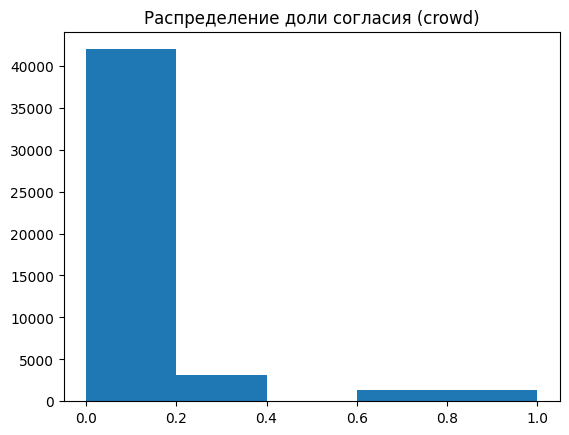

In [43]:
plt.hist(crowd['agree_ratio'], bins=5)
plt.title('Распределение доли согласия (crowd)')
plt.show()

Оценки краудсорсинга содержат 47830 строк на 1000 уникальных изображений. Описаний так же 1000 - похоже для краудсорсинга было больше описаний, чем пото оставили в трейне. 
Наиболее часто встречающееся изображение размечалось 120 раз. Один и тот же `comment_id` встречается до 169 раз.

В большинстве случаев исполнители не подтверждают соответствие текста изображению. Распределение сильно смещено к 0.
- Количество подтверждений (agree_count)
    - Среднее: 0.21
    - Медиана: 0
    - Максимум: 5
    - Большинство пар вообще не получили подтверждений.

- Количество отказов (disagree_count)
    - Среднее: 2.82
    - Медиана: 3
    - 75-й перцентиль: 3
    - Максимум: 6
    - В большинстве случаев 3 исполнителя подтверждают несоответствие.

Crowd-оценка уже находится в диапазоне [0, 1] и я могу использовать ее как таргет, но тогда из-за сильного перекоса модель может склоняться к предсказанию низкой вероятности соответствия.

In [44]:
show_df_info(expert, 'Оценки от экспертов')


=== Оценки от экспертов ===

Первые строки:


,image_name,comment_id,expert_1,expert_2,expert_3
0,1056338697_4f7d7ce270.jpg,2549968784_39bfbe44f9.jpg#2,1,1,1
1,1056338697_4f7d7ce270.jpg,2718495608_d8533e3ac5.jpg#2,1,1,2
2,1056338697_4f7d7ce270.jpg,3181701312_70a379ab6e.jpg#2,1,1,2
3,1056338697_4f7d7ce270.jpg,3207358897_bfa61fa3c6.jpg#2,1,2,2
4,1056338697_4f7d7ce270.jpg,3286822339_5535af6b93.jpg#2,1,1,2



Информация о данных:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5822 entries, 0 to 5821
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   image_name  5822 non-null   object
 1   comment_id  5822 non-null   object
 2   expert_1    5822 non-null   int64 
 3   expert_2    5822 non-null   int64 
 4   expert_3    5822 non-null   int64 
dtypes: int64(3), object(2)
memory usage: 227.6+ KB

Описательная статистика:


,image_name,comment_id,expert_1,expert_2,expert_3
count,5822,5822,5822.000000,5822.000000,5822.000000
unique,1000,977,NaN,NaN,NaN
top,3107513635_fe8a21f148.jpg,2600867924_cd502fc911.jpg#2,NaN,NaN,NaN
freq,10,34,NaN,NaN,NaN
mean,NaN,NaN,1.436620,1.624356,1.881999
std,NaN,NaN,0.787084,0.856222,0.904087
min,NaN,NaN,1.000000,1.000000,1.000000
25%,NaN,NaN,1.000000,1.000000,1.000000
50%,NaN,NaN,1.000000,1.000000,2.000000
75%,NaN,NaN,2.000000,2.000000,2.000000


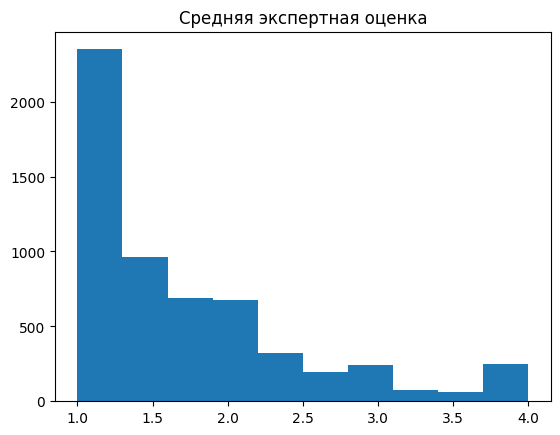

In [45]:
expert['expert_mean'] = expert[['expert_1','expert_2','expert_3']].mean(axis=1)

plt.hist(expert['expert_mean'], bins=10)
plt.title('Средняя экспертная оценка')
plt.show()

Оценки экспертов содержат 5822 строк на 1000 уникальных изображений. Описаний 977 - как в трейне. 
Наиболее часто встречающееся изображение размечалось 10 раз. Один и тот же `comment_id` встречается до 34 раз. Здесь выборка соответствует данным трейна.

Распределение оценок сильно смещено к нижней границе шкалы (у всех экспертов медиана ниже 2). Шкала оценок от 1 до 4. Оценки 3,4 встречаются редко.

Экспертная разметка менее экстремальна, чем crowd, но также смещена к низким оценкам.

Проверим соответствие описаний в трейне, крауд и эксперт

In [46]:
set(train['query_id']) - set(crowd['comment_id'])

set()

In [47]:
set(train['query_id']) - set(expert['comment_id'])

set()

In [48]:
crowd_ids = set(crowd['comment_id'])
expert_ids = set(expert['comment_id'])

len(crowd_ids - expert_ids)

23

Все согласуется, в крауд действительно было на 23 описания больше. Они удалятся при соединении таблиц.

Проверим согласованность экспертов.

In [49]:
expert['std'] = expert[['expert_1','expert_2','expert_3']].std(axis=1)
expert['std'].describe()

count    5822.000000
mean        0.253775
std         0.309257
min         0.000000
25%         0.000000
50%         0.000000
75%         0.577350
max         1.732051
Name: std, dtype: float64

Эксперты демонстрируют высокую согласованность оценок. Большинство пар изображение–текст имеют одинаковую или близкую оценку у всех трёх специалистов.

Это позволяет использовать среднее значение как устойчивый таргет.

Посмотрим как коррелируются оценки крауд и экспертов. для этого возьмем среднее оценок по трем экспертам.

In [50]:
expert_pairs = set(zip(expert["image_name"].astype(str), expert["comment_id"].astype(str)))
crowd_pairs  = set(zip(crowd["image_name"].astype(str),  crowd["comment_id"].astype(str)))

print("pairs expert:", len(expert_pairs))
print("pairs crowd :", len(crowd_pairs))
print("intersection:", len(expert_pairs & crowd_pairs))

pairs expert: 5822
pairs crowd : 47830
intersection: 2329


crowd-разметка есть только для части пар из expert/train, а именно для 2329.

In [51]:
merged = expert.merge(crowd, on=['image_name', 'comment_id'])
merged['expert_mean'] = merged[['expert_1','expert_2','expert_3']].mean(axis=1)
merged[['expert_mean','agree_ratio']].corr()

,expert_mean,agree_ratio
expert_mean,1.000000,0.790782
agree_ratio,0.790782,1.000000


Мы видим высокую корреляцию. Оценки в целом похожи, но имеют незначительные различия.

Так как разметка crowd доступна не для всех пар изображение–текст, а экспертная разметка покрывает весь обучающий набор и обеспечивает более устойчивую и согласованную оценку соответствия - в качестве целевой переменной я буду использовать таргет, сформированный на основе экспертных оценок.

In [52]:
expert_target = expert.copy()

# Средняя оценка экспертов
expert_target["expert_mean"] = expert_target[
    ["expert_1", "expert_2", "expert_3"]
].mean(axis=1)

# Нормализация в диапазон [0,1]
expert_target["target"] = (expert_target["expert_mean"] - 1) / 3

expert_target = expert_target[
    ["image_name", "comment_id", "target"]
]

expert_target["target"].describe()

count    5822.000000
mean        0.215886
std         0.268735
min         0.000000
25%         0.000000
50%         0.111111
75%         0.333333
max         1.000000
Name: target, dtype: float64

In [53]:
train = train.merge(
    expert_target,
    left_on=["image", "query_id"],
    right_on=["image_name", "comment_id"],
    how="left"
).drop(columns=["image_name", "comment_id"])

print(train["target"].describe())
print("Размер train:", train.shape)
print("Пропуски target:", train["target"].isna().sum())

count    5822.000000
mean        0.215886
std         0.268735
min         0.000000
25%         0.000000
50%         0.111111
75%         0.333333
max         1.000000
Name: target, dtype: float64
Размер train: (5822, 4)
Пропуски target: 0


Порог классификации буду подбирать на валидационной выборке для максимизации F1-score.

### Анализ текстов

Для начала посмотрим количество описаний на одну фотографию. В исходных данных говорится о 5 описаниях.

In [54]:
train.groupby('image')['query_id'].count().describe() 

count    1000.000000
mean        5.822000
std         1.583927
min         2.000000
25%         5.000000
50%         6.000000
75%         7.000000
max        10.000000
Name: query_id, dtype: float64

In [55]:
train.groupby('image')['query_id'] \
     .count() \
     .loc[lambda x: x > 5]

image
1056338697_4f7d7ce270.jpg    8
106490881_5a2dd9b7bd.jpg     8
1084040636_97d9633581.jpg    6
1107246521_d16a476380.jpg    6
1119015538_e8e796281e.jpg    7
                            ..
925491651_57df3a5b36.jpg     6
929679367_ff8c7df2ee.jpg     6
968081289_cdba83ce2e.jpg     7
979383193_0a542a059d.jpg     8
997722733_0cb5439472.jpg     8
Name: query_id, Length: 558, dtype: int64

558 фото из 1000 (больше половины) имеют больше 5 описаний - до 10.

In [56]:
#длина описаний
train['text_length'] = train['query_text'].apply(lambda x: len(str(x).split()))

train['text_length'].describe()

count    5822.000000
mean       11.900550
std         4.162467
min         2.000000
25%         9.000000
50%        11.000000
75%        14.000000
max        34.000000
Name: text_length, dtype: float64

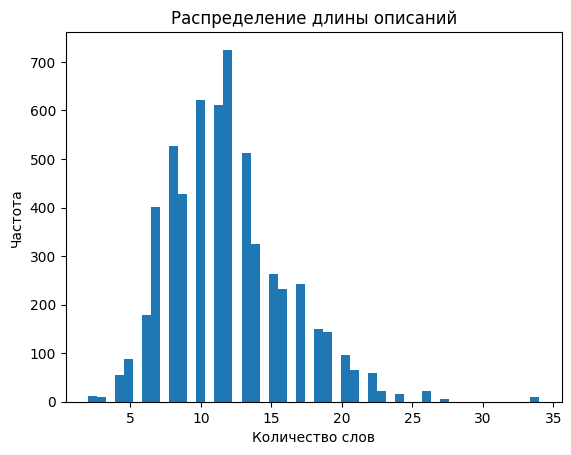

In [57]:
plt.hist(train['text_length'], bins=50)
plt.title('Распределение длины описаний')
plt.xlabel('Количество слов')
plt.ylabel('Частота')
plt.show()

Большинство описаний являются короткими и лаконичными. Распределение достаточно компактное — стандартное отклонение невысокое.
Длинных текстов немного (max = 34 слова), выраженных выбросов нет. Небольшая длина текстов делает возможным использование как TF-IDF, так и BERT

Посмотрим соответствие фото и описаний.

In [58]:
def render_train_queries_for_image(train, image_path, image_name, k=None):
    sub = train.loc[train['image'] == image_name, ['query_id', 'query_text']].drop_duplicates()
    if k is not None:
        sub = sub.head(k)

    rows = []
    for i, (qid, txt) in enumerate(sub.itertuples(index=False), start=1):
        rows.append({
            "qid": i,                 
            "comment_id": qid,        
            "text": str(txt)
        })

    # 3) Рисуем
    img = mpimg.imread(image_path)

    fig = plt.figure(figsize=(14, 6))
    gs = fig.add_gridspec(1, 2, width_ratios=[1.25, 1], wspace=0.05)

    ax_img = fig.add_subplot(gs[0, 0])
    ax_txt = fig.add_subplot(gs[0, 1])

    ax_img.imshow(img)
    ax_img.axis('off')
    ax_img.set_title(f"Изображение: {image_name}", fontsize=12)

    ax_txt.axis('off')

    lines = []
    lines.append("🧾 ЗАПРОСЫ К ИЗОБРАЖЕНИЮ:")
    lines.append("=" * 34)

    for r in rows:
        lines.append(f"□ Запрос {r['qid']}:")
        lines.append(f"  ID: {r['comment_id']}")
        wrapped = textwrap.fill("  Текст: " + r['text'], width=45, subsequent_indent="        ")
        lines.append(wrapped)
        lines.append("-" * 34)

    lines.append(f"□ Всего запросов: {len(rows)}")

    ax_txt.text(
        0.02, 0.98, "\n".join(lines),
        va='top', ha='left',
        fontsize=10,
        family='monospace',
        bbox=dict(boxstyle="round,pad=0.6",
                  facecolor="#e8f4ff",
                  edgecolor="#9bb9d6")
    )

    plt.show()

c:\Users\malen\OneDrive\Desktop\data_since\мастерская 1\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 129534 (\N{RECEIPT}) missing from font(s) DejaVu Sans Mono.
  fig.canvas.print_figure(bytes_io, **kw)


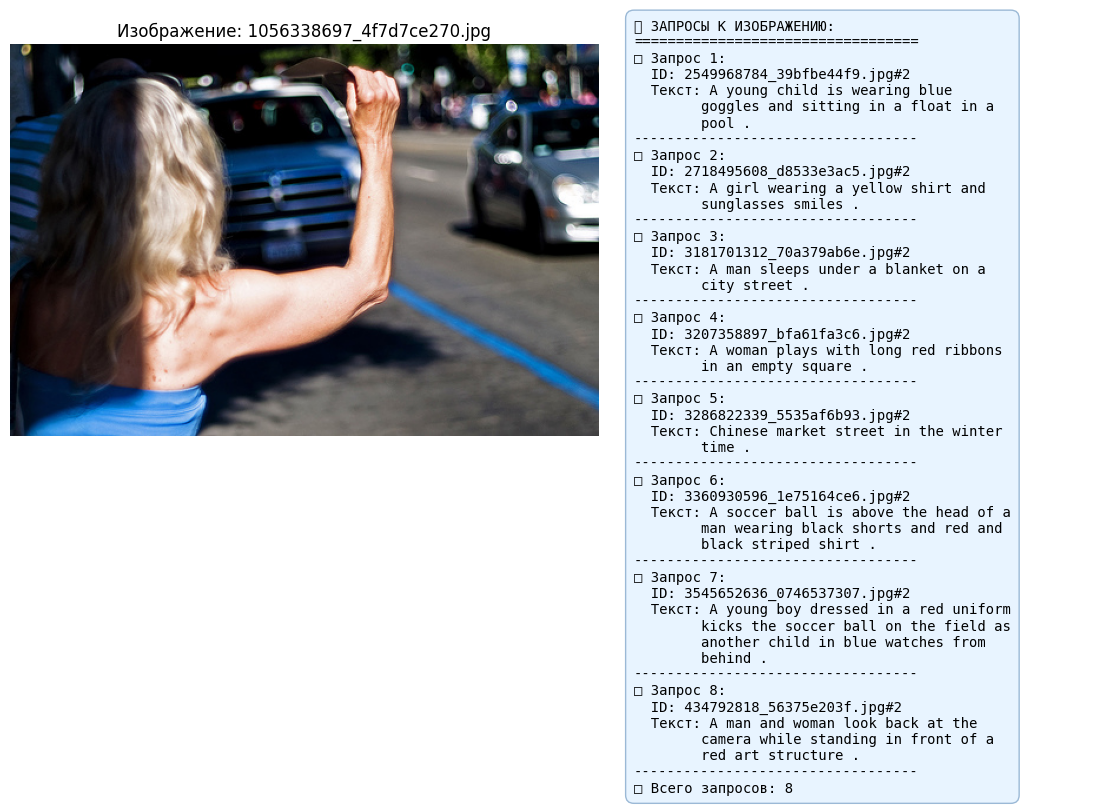

In [59]:
image_name = train['image'].iloc[0]  # первая картинка
image_path = f"C:/Users/malen/OneDrive/Desktop/data_since/cv_nlp/data/train_images/{image_name}"

render_train_queries_for_image(train, image_path, image_name)

Дополнительно проверю согласованности распределений описаний в train и test.

In [60]:
test['query_length'] = test['query_text'].apply(lambda x: len(str(x).split()))
test['query_length'].describe() 

count    500.000000
mean      12.196000
std        4.116732
min        4.000000
25%        9.000000
50%       12.000000
75%       14.000000
max       31.000000
Name: query_length, dtype: float64

Распределения длины текстов в обучающей и тестовой выборках статистически согласованы.
- Средняя длина практически одинакова - 11.9 (train) vs 12.2 (test)
- Стандартное отклонение почти совпадает - 4.16 vs 4.12
- Медианы близки - 11 vs 12
- Диапазоны схожи - 2–34 (train) и 4–31 (test)

## Проверка данных

В некоторых странах, где работает ваша компания, действуют ограничения по обработке изображений: поисковым сервисам и сервисам, предоставляющим возможность поиска, запрещено без разрешения родителей или законных представителей предоставлять любую информацию, в том числе, но не исключительно тексты, изображения, видео и аудио, содержащие описание, изображение или запись голоса детей. Ребёнком считается любой человек, не достигший 16 лет.

В нашем сервисе строго следуют законам стран, в которых работают. Поэтому при попытке посмотреть изображения, запрещённые законодательством, вместо картинок показывается дисклеймер:

"This image is unavailable in your country in compliance with local laws"

Однако у нас нет возможности воспользоваться данным функционалом. Поэтому все изображения, которые нарушают данный закон, нужно удалить из обучающей выборки.

Для начала сделаем список слов, которые явно указывают на несовершеннолетних.

In [ ]:
child_keywords = [
    'child', 'children', 'kid', 'kids',
    'boy', 'girl', 'toddler', 'baby',
    'teen', 'teenager', 'schoolboy',
    'schoolgirl', 'minor', 'girls', 'boys', 'teenagers'
]

In [62]:
train['query_text_lower'] = train['query_text'].str.lower()

In [63]:
def contains_child(text):
    for word in child_keywords:
        if re.search(rf"\b{word}\b", text):
            return True
    return False

train['contains_child'] = train['query_text_lower'].apply(contains_child)
train['contains_child'].sum()

1334

1334 строки потенциально содержат описание ребенка.

In [64]:
train = train[~train['contains_child']]
print(train.shape)
print(train['image'].unique().shape)

(4488, 7)
(995,)


Из обучающей выборки удалено 1334 строки, содержащих упоминание несовершеннолетних. Из 1000 осталось 995 фото.

В тестовой выборке при обнаружении подобных триггеров будет выводится дисклеймер вместо результата модели.

## Векторизация изображений

Для задачи поиска изображений по текстовому описанию требуется модель, которая способна сопоставлять текст и изображения в общем семантическом пространстве.

Модель CLIP (Contrastive Language–Image Pretraining) обучена на большом наборе пар «изображение–текст» и позволяет:
- кодировать изображение и текст в одно общее векторное пространство;
- измерять степень соответствия через косинусное сходство;
- использовать модель без дополнительного обучения (подходит для PoC).

В отличие от комбинации ResNet + BERT, CLIP изначально оптимизирован для multimodal-matching, что делает его более подходящим решением для данной задачи.

In [65]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
clip_model = CLIPModel.from_pretrained(MODEL_NAME).to(device)
clip_model.eval()

clip_processor = CLIPProcessor.from_pretrained(MODEL_NAME)

In [66]:
@torch.no_grad()
def get_image_embedding(image_path: str) -> torch.Tensor:
    """
    Возвращает нормализованный embedding изображения.
    Размерность: (512,)
    """
    image = Image.open(image_path).convert("RGB")

    inputs = clip_processor(images=image, return_tensors="pt")
    inputs = {k: v.to(device) for k, v in inputs.items()}

    embedding = clip_model.get_image_features(**inputs)

    # Нормализация для cosine similarity
    embedding = F.normalize(embedding, dim=-1)

    return embedding.squeeze(0).cpu()

In [67]:
def build_image_embeddings(train_df: pd.DataFrame,
                           images_dir: str,
                           image_col: str = "image",
                           save_path="clip_image_embeddings.pt") -> dict:
    """
    Возвращает dict: {image_name: embedding_tensor(512,)}
    """
    image_embeddings = {}
    missing_files = []

    unique_images = train_df[image_col].unique()

    for i, image_name in enumerate(unique_images, start=1):
        image_path = os.path.join(images_dir, image_name)

        if not os.path.exists(image_path):
            missing_files.append(image_name)
            continue

        image_embeddings[image_name] = get_image_embedding(image_path)

        if i % 100 == 0:
            print(f"Обработано {i}/{len(unique_images)} изображений")

    if missing_files:
        print(f"\n Не найдено файлов: {len(missing_files)}")
        print("Примеры:", missing_files[:5])
    
    torch.save(image_embeddings, save_path)
    print(f"\nЭмбеддинги сохранены в файл: {save_path}")

    return image_embeddings

In [68]:
image_embeddings = build_image_embeddings(train, TRAIN_PATH, IMAGE_COL)

print("\nГотово!")
print("Уникальных изображений в train:", train[IMAGE_COL].nunique())
print("Получено эмбеддингов:", len(image_embeddings))

# Проверка размерности одного эмбеддинга
any_img = next(iter(image_embeddings))
print("Пример файла:", any_img)
print("Размер эмбеддинга:", image_embeddings[any_img].shape)

Обработано 100/995 изображений
Обработано 200/995 изображений
Обработано 300/995 изображений
Обработано 400/995 изображений
Обработано 500/995 изображений
Обработано 600/995 изображений
Обработано 700/995 изображений
Обработано 800/995 изображений
Обработано 900/995 изображений

Эмбеддинги сохранены в файл: clip_image_embeddings.pt

Готово!
Уникальных изображений в train: 995
Получено эмбеддингов: 995
Пример файла: 1056338697_4f7d7ce270.jpg
Размер эмбеддинга: torch.Size([512])


## Векторизация текста

Для получения текстовых эмбеддингов используется та же модель CLIP, что и для изображений.

In [69]:
@torch.no_grad()
def get_text_embedding(text: str) -> torch.Tensor:
    """
    Возвращает нормализованный embedding текста.
    Размерность: (512,)
    """
    inputs = clip_processor(
        text=[text],
        return_tensors="pt",
        padding=True,
        truncation=True
    )

    inputs = {k: v.to(device) for k, v in inputs.items()}

    embedding = clip_model.get_text_features(**inputs)

    # Нормализация
    embedding = F.normalize(embedding, dim=-1)

    return embedding.squeeze(0).cpu()

In [70]:
def build_text_embeddings(train_df,
                          text_col="query_text",
                          id_col="query_id",
                          save_path="clip_text_embeddings.pt"):
    """
    Возвращает dict: {query_id: embedding_tensor(512,)}
    И сохраняет эмбеддинги в файл.
    """

    text_embeddings = {}

    # Берём уникальные пары id + текст
    unique_texts = train_df[[id_col, text_col]].drop_duplicates()

    for i, (qid, text) in enumerate(unique_texts.values, start=1):
        
        text_embeddings[qid] = get_text_embedding(text)

        if i % 500 == 0:
            print(f"Обработано {i}/{len(unique_texts)} текстов")

    # Сохранение
    torch.save(text_embeddings, save_path)
    print(f"\nТекстовые эмбеддинги сохранены в файл: {save_path}")

    return text_embeddings


In [71]:
text_embeddings = build_text_embeddings(
    train_df=train,
    text_col="query_text",
    id_col="query_id"
)

print("\nГотово!")
print("Уникальных текстов в train:", train["query_id"].nunique())
print("Получено эмбеддингов:", len(text_embeddings))

# Проверка размерности одного эмбеддинга
any_text = next(iter(text_embeddings))
print("Пример query_id:", any_text)
print("Размер эмбеддинга:", text_embeddings[any_text].shape)

Обработано 500/731 текстов

Текстовые эмбеддинги сохранены в файл: clip_text_embeddings.pt

Готово!
Уникальных текстов в train: 731
Получено эмбеддингов: 731
Пример query_id: 3181701312_70a379ab6e.jpg#2
Размер эмбеддинга: torch.Size([512])


## Объединение векторов

Для оценки соответствия изображения и текстового описания я буду использовать косинусное сходство между их эмбеддингами.

Модель CLIP обучена в режиме контрастивного обучения и формирует общее семантическое пространство признаков для изображений и текста. Это означает, что векторы обеих модальностей уже согласованы между собой, и степень их соответствия может быть напрямую измерена через косинусное сходство.

In [72]:
def build_similarity_dataframe(train,
                               image_embeddings,
                               text_embeddings,
                               image_col="image",
                               id_col="query_id",
                               target_col="target"):
    """
    Возвращает DataFrame:
    image | query_id | similarity | target
    """
    rows = []

    for _, r in train.iterrows():
        img = r[image_col]
        qid = r[id_col]

        # пропускаем, если нет эмбеддингов
        if img not in image_embeddings or qid not in text_embeddings:
            continue

        img_emb = image_embeddings[img]      # (512,)
        txt_emb = text_embeddings[qid]       # (512,)

        # cosine similarity (эмбеддинги уже нормализованы)
        sim = float((img_emb * txt_emb).sum())

        rows.append({
            "image": img,
            "query_id": qid,
            "similarity": sim,
            "target": float(r[target_col])
        })

    return pd.DataFrame(rows)

In [73]:
train_sim = build_similarity_dataframe(
    train=train,
    image_embeddings=image_embeddings,
    text_embeddings=text_embeddings,
    image_col="image",
    id_col="query_id",
    target_col="target"
)

print(train_sim.shape)
print(train_sim.head())

(4488, 4)
                       image                     query_id  similarity  \
0  1056338697_4f7d7ce270.jpg  3181701312_70a379ab6e.jpg#2    0.158563   
1  3187395715_f2940c2b72.jpg  3181701312_70a379ab6e.jpg#2    0.188871   
2   463978865_c87c6ca84c.jpg  3181701312_70a379ab6e.jpg#2    0.233499   
3   488590040_35a3e96c89.jpg  3181701312_70a379ab6e.jpg#2    0.143895   
4   534875358_6ea30d3091.jpg  3181701312_70a379ab6e.jpg#2    0.169973   

     target  
0  0.111111  
1  0.222222  
2  0.333333  
3  0.222222  
4  0.111111  


В результате объединения эмбеддингов изображений и текстов была сформирована итоговая таблица размерности (4488, 4).
Каждая строка таблицы соответствует одной паре «изображение — текстовое описание» и содержит следующие столбцы:
- `image` — имя файла изображения;
- `query_id` — идентификатор текстового описания;
- `similarity` — косинусное сходство между эмбеддингами изображения и текста, полученными с помощью модели CLIP;
- `target` — целевая переменная (степень соответствия изображения и текста, сформированная на основе экспертных оценок).

## Обучение модели предсказания соответствия

Для корректного разделения выборки использую GroupShuffleSplit.

In [74]:
gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

groups = train_sim["image"]  # группируем по изображению

train_idx, val_idx = next(gss.split(train_sim, groups=groups))

train_split = train_sim.iloc[train_idx].reset_index(drop=True)
val_split = train_sim.iloc[val_idx].reset_index(drop=True)

print("Train size:", train_split.shape)
print("Valid size:", val_split.shape)

Train size: (3558, 4)
Valid size: (930, 4)


Проверим, что изображения не пересекаются

In [75]:
train_images = set(train_split["image"])
val_images = set(val_split["image"])

print("Пересечение изображений:", len(train_images & val_images))

Пересечение изображений: 0


Баланс классов

In [76]:
print("Train target distribution:")
print(train_split["target"].value_counts(normalize=True))

print("\nValid target distribution:")
print(val_split["target"].value_counts(normalize=True))

Train target distribution:
target
0.000000    0.385891
0.111111    0.170039
0.222222    0.112704
0.333333    0.109331
0.444444    0.061832
1.000000    0.049466
0.666667    0.047218
0.555556    0.036818
0.777778    0.015177
0.888889    0.011523
Name: proportion, dtype: float64

Valid target distribution:
target
0.000000    0.418280
0.111111    0.131183
0.333333    0.127957
0.222222    0.121505
0.444444    0.054839
0.666667    0.043011
1.000000    0.040860
0.555556    0.033333
0.777778    0.016129
0.888889    0.012903
Name: proportion, dtype: float64


Для расчета метрики ROC-AUC переведем таргет в бинарный вид. с учетом что оценки были в диапозоне 1-4, мы считаем, что текст подходит к фото, если средняя экспертная оценка ≥ 3.

In [78]:
train_split["target_bin"] = (train_split["target"] >= 2/3).astype(int)
val_split["target_bin"] = (val_split["target"] >= 2/3).astype(int)

train_auc = roc_auc_score(train_split["target_bin"], train_split["similarity"])
val_auc = roc_auc_score(val_split["target_bin"], val_split["similarity"])

print("Train ROC-AUC:", round(train_auc, 4))
print("Valid ROC-AUC:", round(val_auc, 4))

Train ROC-AUC: 0.9432
Valid ROC-AUC: 0.9339


Как видно по метрикам - Zero-shot CLIP уже отлично подходит для задачи фотохостинга.

Подбор порога для F1

In [91]:
def find_best_threshold(y_true, scores, grid=None):
    thresholds = np.linspace(-1, 1, 200)
    best_thr = 0
    best_f1 = 0

    for t in thresholds:
        preds = (scores >= t).astype(int)
        f1 = f1_score(y_true, preds)

        if f1 > best_f1:
            best_f1 = f1
            best_thr = t

    return best_thr, best_f1

In [81]:
best_thr, best_f1 = find_best_threshold(
    train_split["target_bin"].values,
    train_split["similarity"].values
)

print("Лучший порог:", round(best_thr, 4))
print("F1 на train:", round(best_f1, 4))

Лучший порог: 0.2864
F1 на train: 0.6674


In [83]:
val_preds = (val_split["similarity"] >= best_thr).astype(int)

from sklearn.metrics import classification_report

print(classification_report(val_split["target_bin"], val_preds))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       825
           1       0.61      0.61      0.61       105

    accuracy                           0.91       930
   macro avg       0.78      0.78      0.78       930
weighted avg       0.91      0.91      0.91       930



Модель CLIP без дополнительного дообучения показала высокое качество разделения соответствующих и несоответствующих пар изображение–текст (ROC-AUC ≈ 0.93).

После подбора оптимального порога классификации достигнут F1-score 0.61 для положительного класса при общем accuracy 0.91.

С учётом выраженного дисбаланса классов полученные результаты демонстрируют практическую применимость модели для задачи поиска референсных изображений.

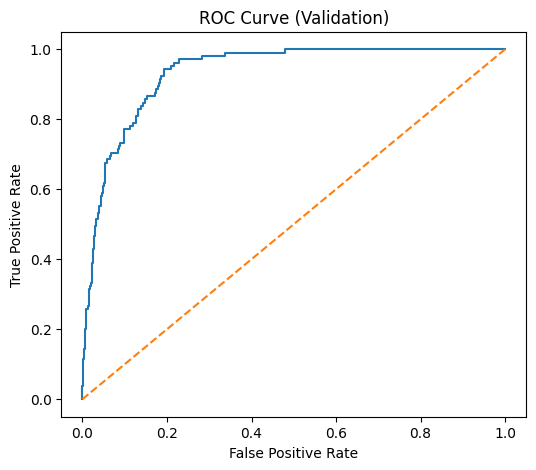

In [87]:
fpr, tpr, _ = roc_curve(val_split["target_bin"], val_split["similarity"])

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Validation)")
plt.show()

Таким образом, я использовала CLIP zero-shot, которая показала F1-score 0.61 на пороге 0.29. При этом у нас сильный дисбаланс классов и модель хорошо предсказывает не соответствие картинка-текст.

## Тестирование модели

После обучения и оценки качества модели на обучающей выборке необходимо проверить её работу в режиме реального поиска.

Цель данного этапа — продемонстрировать, как модель обрабатывает новые текстовые запросы и ранжирует изображения по степени их соответствия описанию.

Как и планировала, я буду вставлять дисклеймер, при попадании описания о ребенке. Для вывода релевантных изображений я создала изображение-дисклеймер.

In [216]:
DISCLAIMER_IMAGE = "DISCLAIMER.jpeg"
DISCLAIMER = "This image is unavailable in your country in compliance with local laws"

def check_query_for_child(text):
    text = text.lower()
    return any(re.search(rf"\b{word}\b", text) for word in child_keywords)


# определяем какие строки содержат детские слова
test["contains_child"] = test["query_text"].apply(check_query_for_child)

# агрегируем по изображению
image_child_flag = (
    test.groupby("image")["contains_child"]
    .any()   # если хотя бы одно True
)

# формируем set запрещённых изображений
banned_images = set(
    image_child_flag[image_child_flag].index
)

print("Количество запрещённых изображений:", len(banned_images))

Количество запрещённых изображений: 44


Теперь получим эмбендинги изображений и текста для тестового набора.

In [98]:
test_image_embeddings = build_image_embeddings(test, TEST_PATH, IMAGE_COL)

print("\nГотово!")
print("Уникальных изображений в test:", test[IMAGE_COL].nunique())
print("Получено эмбеддингов:", len(test_image_embeddings))

# Проверка размерности одного эмбеддинга
any_img = next(iter(test_image_embeddings))
print("Пример файла:", any_img)
print("Размер эмбеддинга:", test_image_embeddings[any_img].shape)

Обработано 100/100 изображений

Эмбеддинги сохранены в файл: clip_image_embeddings.pt

Готово!
Уникальных изображений в test: 100
Получено эмбеддингов: 100
Пример файла: 1177994172_10d143cb8d.jpg
Размер эмбеддинга: torch.Size([512])


In [99]:
test_text_embeddings = build_text_embeddings(
    train_df=test,
    text_col="query_text",
    id_col="query_id"
)

print("\nГотово!")
print("Уникальных текстов в test:", test["query_id"].nunique())
print("Получено эмбеддингов:", len(test_text_embeddings))

# Проверка размерности одного эмбеддинга
any_text = next(iter(test_text_embeddings))
print("Пример query_id:", any_text)
print("Размер эмбеддинга:", test_text_embeddings[any_text].shape)

Обработано 500/500 текстов

Текстовые эмбеддинги сохранены в файл: clip_text_embeddings.pt

Готово!
Уникальных текстов в test: 500
Получено эмбеддингов: 500
Пример query_id: 1177994172_10d143cb8d.jpg#0
Размер эмбеддинга: torch.Size([512])


Для проведения практической проверки работы модели я буду использовать поиск в формате Top-3.

Под Top-3 понимается выбор 3 наиболее релевантных изображений для каждого текстового запроса — отбор по максимальному значение косинусного сходства с эмбеддингом запроса.

In [208]:
def retrieve_top_k_images(query_text: str,
                          image_embeddings: dict,
                          banned_images: set,
                          k: int = 3):
    """
    Возвращает список топ-k:
    [(image_name или DISCLAIMER.jpeg, similarity), ...]
    """

    q_emb = get_text_embedding(query_text)  # (512,)

    image_names = list(image_embeddings.keys())
    img_mat = torch.stack([image_embeddings[n] for n in image_names])

    sims = (img_mat * q_emb).sum(dim=1)

    topk_vals, topk_idx = torch.topk(sims, k=min(k, len(image_names)))

    results = []

    for j, idx in enumerate(topk_idx.cpu().numpy()):
        img_name = image_names[idx]
        sim_val = float(topk_vals[j])

        # если запрещено → заменяем
        if img_name in banned_images:
            results.append((DISCLAIMER_IMAGE, sim_val))
        else:
            results.append((img_name, sim_val))

    return results

In [209]:
def show_random_queries_results(test_df,
                               test_images_dir,
                               image_embeddings,
                               n_queries=10,
                               query_text_col="query_text",
                               relevant_image_col="image",
                               k=3):

    sample_df = test_df.sample(n=min(n_queries, len(test_df))).reset_index(drop=True)

    for i, row in sample_df.iterrows():
        qtext = row[query_text_col]
        gt = row[relevant_image_col] if relevant_image_col in sample_df.columns else None

        print("=" * 80)
        print(f"[{i+1}] \033[1m\nQuery \033[0m: {qtext}")

        # дисклеймер
        if check_query_for_child(qtext):
            print("\n" + DISCLAIMER + "\n")
            continue

        topk = retrieve_top_k_images(qtext, image_embeddings, banned_images, k=k)
        print("TopK:", topk[:min(3, len(topk))])

        if len(topk) == 0:
            print("Нет результатов поиска (topk пустой).")
            continue

        fig, axes = plt.subplots(1, len(topk), figsize=(3.2 * len(topk), 3.5))
        if len(topk) == 1:
            axes = [axes]

        for ax, item in zip(axes, topk):
            img_name, sim = item[0], item[1]

            img_path = os.path.join(test_images_dir, img_name)
            if not os.path.exists(img_path):
                ax.set_title("File not found")
                ax.axis("off")
                continue

            img = Image.open(img_path).convert("RGB")
            ax.imshow(img)
            ax.axis("off")

            title = f"{img_name}\nsim={sim:.3f}"
            if gt and img_name == gt:
                title += "\n(GT)"
            ax.set_title(title, fontsize=8)

        plt.tight_layout()
        plt.show()

        if relevant_image_col in sample_df.columns:
            rel_img = row[relevant_image_col]
            if isinstance(rel_img, str) and rel_img.strip():
                rel_path = os.path.join(test_images_dir, rel_img)
                if os.path.exists(rel_path):
                    rel = Image.open(rel_path).convert("RGB")
                    plt.figure(figsize=(5, 5))
                    plt.imshow(rel)
                    plt.axis("off")
                    plt.title(f"Исходное изображение: {rel_img}")
                    plt.show()

[1] 
Query : Several dogs are running down a cement and dirt path , with two brown ones in the lead .
TopK: [('3033612929_764d977bd5.jpg', 0.33005568385124207), ('634891010_9fa189effb.jpg', 0.3173336684703827), ('957682378_46c3b07bcd.jpg', 0.3094121217727661)]


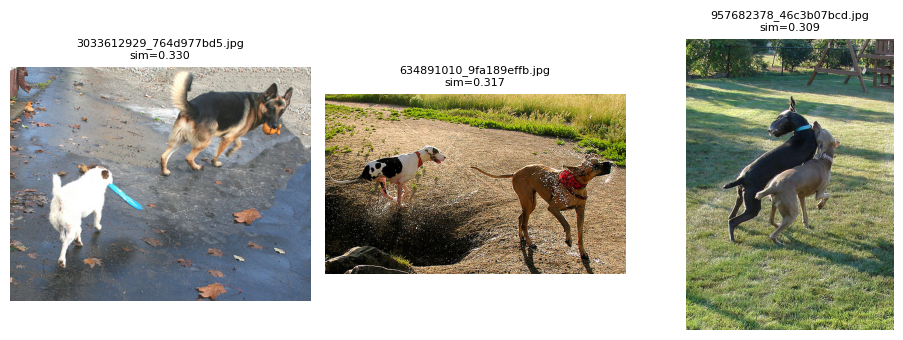

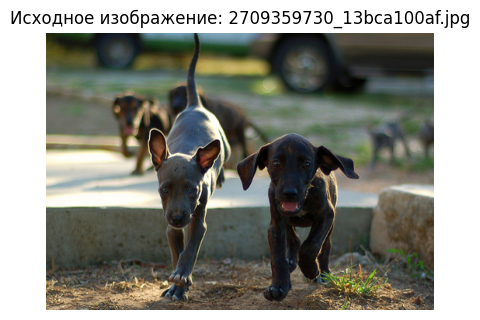

[2] 
Query : a blond man jumping off a cliff into some water
TopK: [('DISCLAIMER.jpeg', 0.30493664741516113), ('345785626_9fa59f38ce.jpg', 0.2785552740097046), ('3036971334_78187a9570.jpg', 0.2751326262950897)]


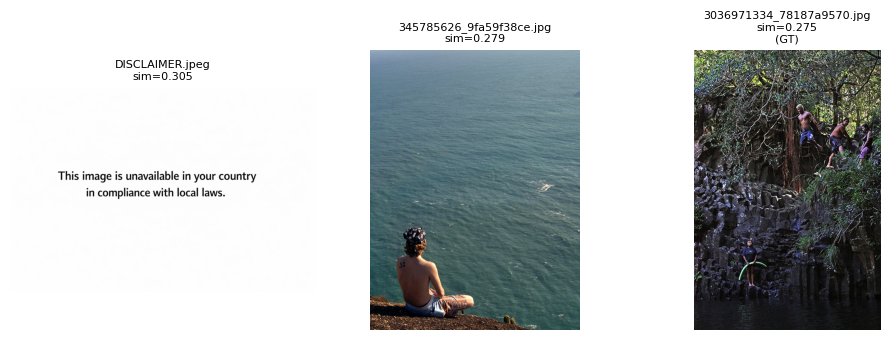

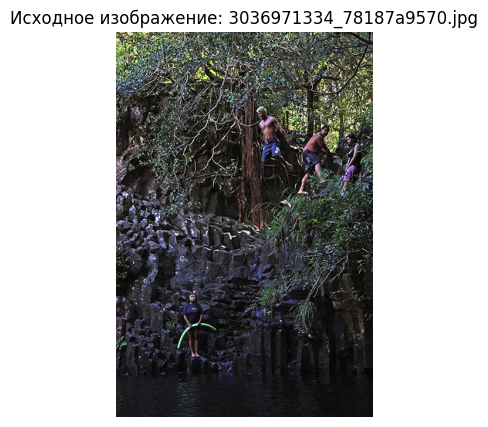

[3] 
Query : An ice skating park in winter , with many people .
TopK: [('269650644_059a84ece5.jpg', 0.3248324990272522), ('DISCLAIMER.jpeg', 0.2469463348388672), ('3089107423_81a24eaf18.jpg', 0.21878445148468018)]


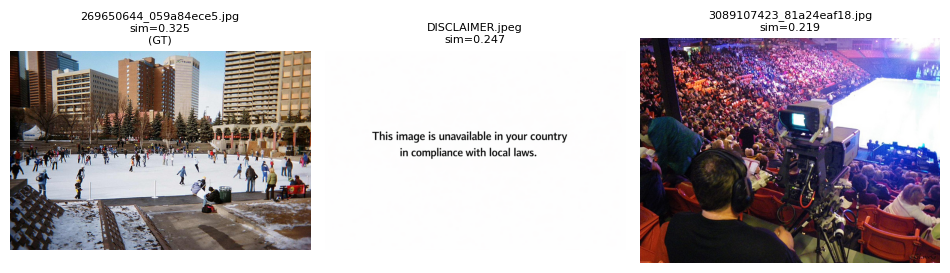

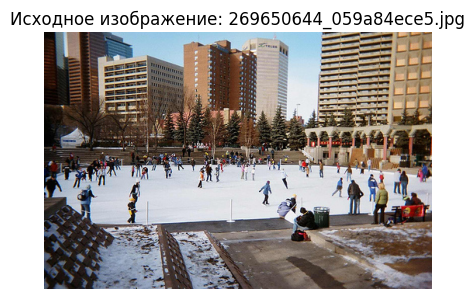

[4] 
Query : Two people are in a tent near a brick wall .
TopK: [('3044745642_1d0784ff29.jpg', 0.32033440470695496), ('3520936130_9e90872560.jpg', 0.271452397108078), ('3173157541_70b16b4318.jpg', 0.2466864287853241)]


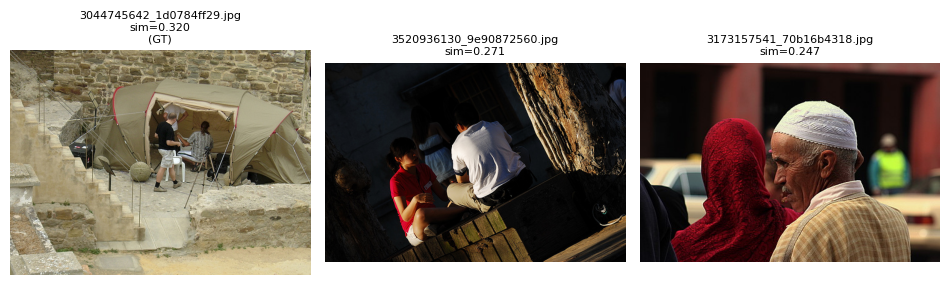

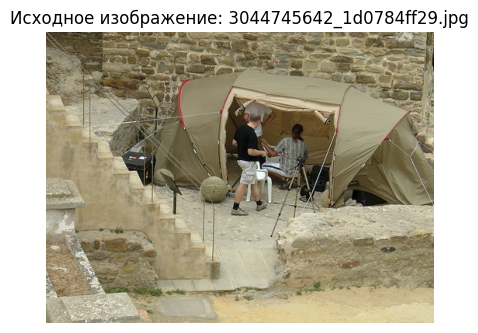

[5] 
Query : A man with a white hat and plaid shirt behind a woman with a red headdress .
TopK: [('DISCLAIMER.jpeg', 0.31376269459724426), ('3173157541_70b16b4318.jpg', 0.29207268357276917), ('DISCLAIMER.jpeg', 0.29084092378616333)]


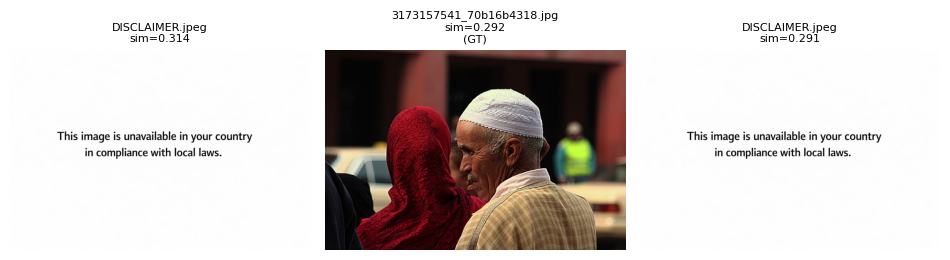

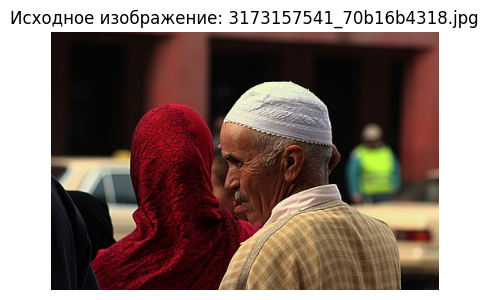

[6] 
Query : Four people playing basketball on wooden area near the beach .
TopK: [('DISCLAIMER.jpeg', 0.34363240003585815), ('DISCLAIMER.jpeg', 0.24893146753311157), ('DISCLAIMER.jpeg', 0.22676287591457367)]


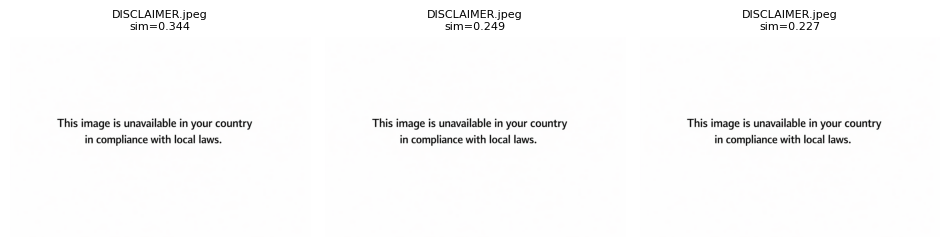

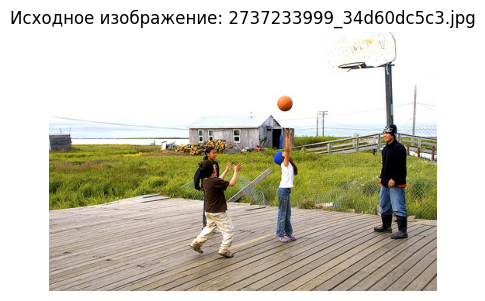

[7] 
Query : Several dogs are running through the dirt .
TopK: [('634891010_9fa189effb.jpg', 0.3028637170791626), ('957682378_46c3b07bcd.jpg', 0.29685166478157043), ('1429546659_44cb09cbe2.jpg', 0.2928919494152069)]


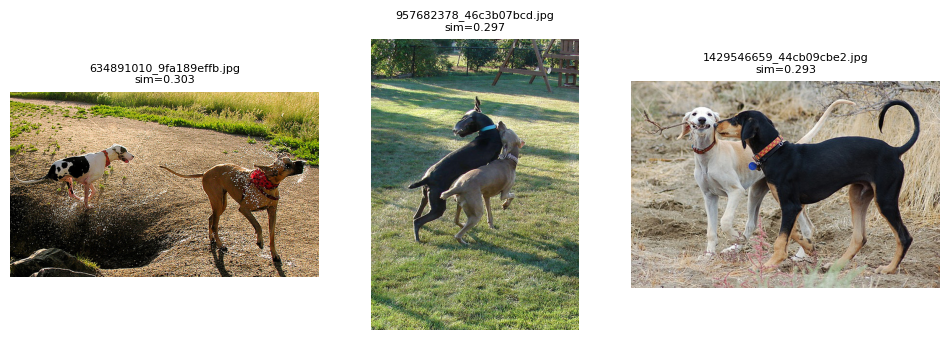

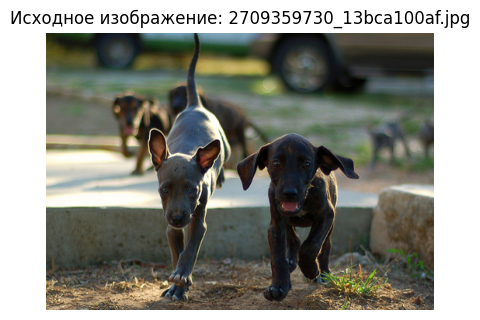

[8] 
Query : Two men are standing under a large work of art by a brick building .
TopK: [('3601978895_9fec23ce0c.jpg', 0.3191041052341461), ('DISCLAIMER.jpeg', 0.26281195878982544), ('3211199368_ca78387f72.jpg', 0.25251805782318115)]


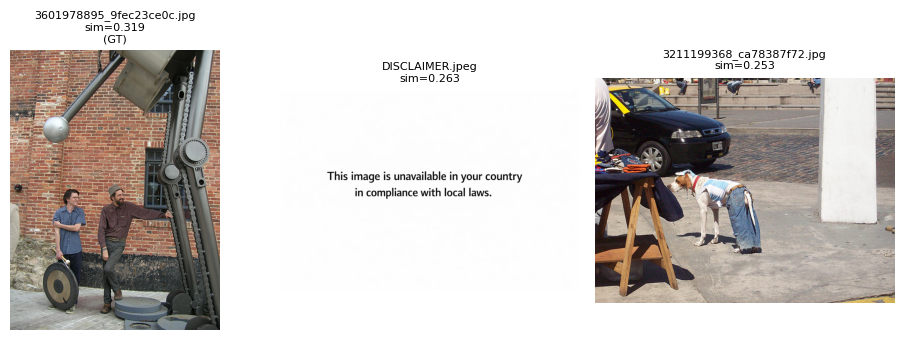

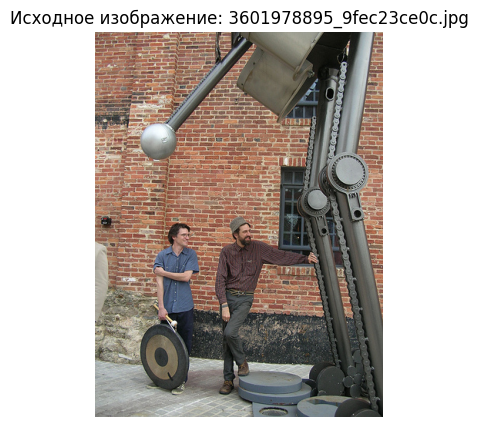

[9] 
Query : Two kids playing with a dog .

This image is unavailable in your country in compliance with local laws

[10] 
Query : kids are playing in water fountains

This image is unavailable in your country in compliance with local laws



In [218]:
show_random_queries_results(
    test_df=test,
    test_images_dir=TEST_PATH,
    image_embeddings=test_image_embeddings,
    n_queries=10,
    query_text_col="query_text",
    relevant_image_col="image",
    k=3
)

Дисклеймер работает, в том числе в топ-3. В целом поисковая система работает корректно - по текстовому описанию выдается топ-3 релевантных фото. Как правило исходное фото входит в топ-5 изображений.

## Вывод

В рамках проекта была реализована демонстрационная версия системы поиска изображений по текстовому описанию на основе zero-shot модели CLIP.

В ходе работы:
- выполнен анализ данных;
- агрегированы экспертные оценки и сформирована целевая переменная (в качестве таргета взята нормализованная средняя оценка экспертов);
- исключён контент, подпадающий под юридические ограничения;
- получены эмбеддинги изображений и текстов;
- реализован поиск на основе косинусного сходства;
- проведена оценка качества на обучающей и валидационной выборках.

Zero-shot CLIP без дополнительного дообучения показал высокое качество разделения соответствующих и несоответствующих пар:
- ROC-AUC ≈ 0.93 на валидации;
- F1-score ≈ 0.61 для положительного класса при выраженном дисбалансе.

В режиме реального поиска (Top-3) модель корректно определяет наиболее релевантные изображения для текстового запроса. Визуальная проверка показала совпадения с ground truth для части случайных запросов, что подтверждает практическую применимость решения.

Таким образом, разработанный Proof of Concept демонстрирует, что использование zero-shot CLIP является технически осуществимым и эффективным подходом для реализации поиска референсных изображений в фотохостинге «With Sense».